# 练习一：逻辑回归模型

在该练习中，我们将要

1. 创建一个简单数据集
   $$
   D = \left\{ \left(\mathbf{x}_i, y_i\right) \in \mathbb{R}^2\times\{0, 1\} \middle| i = 1, 2, \cdots, m \right\}
   $$

   用于之后进行二分类任务。
   
2. 定义逻辑回归模型
   $$
   y = f\left(\mathbf{x}\right) = \sigma\left(\mathbf{w}^T\mathbf{x} + b\right),
   $$
   其中 $\mathbf{w} = \left(w_1, w_2\right) \in \mathbb{R}^2$ 和 $b \in \mathbb{R}$ 都是可训练的参数，$\sigma\left(\cdot\right)$ 是 Sigmoid 函数：
   $$
   \sigma\left(z\right) = \frac{1}{1 + e^{-z}} \in \left(0, 1\right).
   $$
   
3. 使用梯度下降法对参数 $\mathbf{w}$ 和 $b$ 进行训练，其中损失函数为
   $$
   L(\mathbf{w}, b) = -\frac{1}{m}\sum_{i=1}^{m} \left[y_i \log \sigma\left(\mathbf{w}^T\mathbf{x} + b\right) + (1 - y_i) \log\left(1 - \sigma\left(\mathbf{w}^T\mathbf{x} + b\right) \right)  \right].
   $$
   
4.  使用 `scikit-learn` 求解优化问题，并与梯度下降法进行比较。

## 加载所需的包

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import ipywidgets
from ipywidgets import interact

## 可视化辅助代码

In [2]:
def visualize_classification(ax, x, y, θ):
    '''
    平面散点的二分类结果可视化

    输入：
        ax: matplotlib.axes.Axes
        绘图区域对象
        
        x: array[float, N_SAMPLE, 2]
        平面散点的坐标

        y: array[float, N_SAMPLE]
        平面散点的标签（虽然是 float 但是取值只为 0 或 1）

        θ: array[float, 3]
        分界面直线方程的参数，即 θ[0] + θ[1] * x_1 + θ[2] * x_2 = 0
        
    '''
    
    # 绘制样本点
    ax.scatter(x[y == 0, 0], x[y == 0, 1], color="g")
    ax.scatter(x[y == 1, 0], x[y == 1, 1], color="r")

    # 获取画布区域大小
    x_min, x_max = ax.get_xlim() 
    y_min, y_max = ax.get_ylim() 

    # 绘制生成数据时候的分界面
    x_line = np.linspace(x_min, x_max)
    y_line = (θ[0] + θ[1] * x_line) / -θ[2] 
    ax.plot(x_line, y_line, color="k", lw=3)

    # 绘制两个类别所属区域的背景色
    ax.fill_between(x_line, y_line, y_max, color="r", alpha=0.1)
    ax.fill_between(x_line, y_min, y_line, color="g", alpha=0.1)

    # 美化细节
    ax.tick_params(labelsize=18)
    ax.set_xlabel("$x_1$", size=18)
    ax.set_ylabel("$x_2$", size=18)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

## 创建一个简单数据集

__数据集细节__：生成 $m$ 个属于正方形区域 $\left[-1, 1\right]^2$ 的样本点。如果样本 $\mathbf{x}$ 满足 $0.5x_1 - x_2 + 0.1 \le 0$ 则归其标签 $y = 1$， 否则标签 $y = 0$。同时我们假设样本 $\mathbf{x}$ 在测量的时候存在一定噪声，因此实际上观测的 $\mathbf{x}$ 还要加上一定的高斯噪声 $\mathcal{N}(0, \epsilon^2\mathbf{I})$。

In [3]:
# 固定随机数种子
np.random.seed(2025)

# 样本个数
m = 100

# 从正方形区域采样 x
x_sample = np.random.uniform(low=-1.0, high=1.0, size=(m, 2))

# 赋予相应的标签
y_sample = (0.5 * x_sample[:, 0] - x_sample[:, 1] + 0.1 <= 0).astype(float)

# 假设样本 x 在测量的时候存在一定的高斯噪声
x_sample = x_sample + 0.05 * np.random.normal(size=(m, 2))

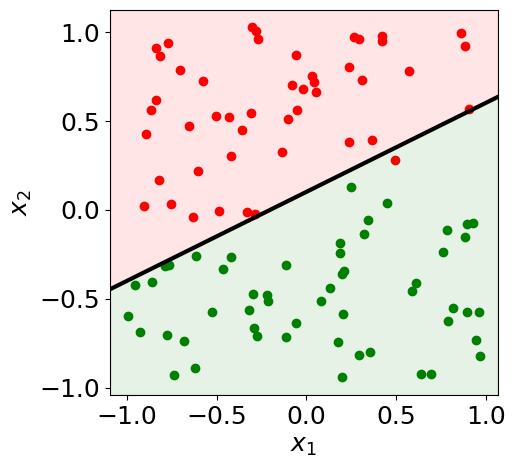

In [4]:
# 可视化数据集

# 创建画布
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# 调用辅助函数
visualize_classification(ax, x_sample, y_sample, θ=[-0.1, -0.5, 1.0])

# 显示图像
plt.show()

## 定义逻辑回归模型

为了便于后续求梯度时统一符号，我们注意到  $\mathbf{w}^T\mathbf{x} + b = \left(b, w_1, w_2\right) \cdot (1, x_1, x_2)$，因此我们可以令 $\boldsymbol{\theta} = \left(b, w_1, w_2\right)$ 以及 $\tilde{\mathbf{x}} = (1, x_1, x_2)$，把模型写成

  $$
  y = f\left(\mathbf{x}\right) = \sigma\left(\boldsymbol{\theta}^T\tilde{\mathbf{x}}\right)
  $$

In [5]:
# 定义激活函数
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

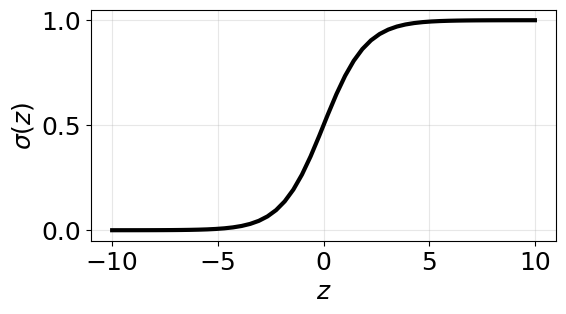

In [6]:
# 可视化激活函数

# 创建画布
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

# 绘制曲线
x_plot = np.linspace(-10.0, +10.0)
y_plot = sigmoid(x_plot)
ax.plot(x_plot, y_plot, color="k", lw=3)

# 美化细节
ax.grid(alpha=0.3)
ax.tick_params(labelsize=18)
ax.set_xlabel("$z$", size=18)
ax.set_ylabel(r"$\sigma(z)$", size=18)

# 显示图像
plt.show()

In [7]:
# 定义逻辑回归模型
def logistic_regression(x, θ):
    """
    计算输入数据 x 在参数 θ 下逻辑回归模型的输出
    
    输入：
        x: array[float, N_SAMPLE, N_DIM]
        θ: array[float, N_DIM]
            
    返回：
        p: array[float, N_SAMPLE]
    """
    # 首先计算 x 和 θ 的内积
    z = np.einsum("ij,j->i", x, θ)
    # 然后应用激活函数
    p = sigmoid(z)
    # 返回模型输出
    return p

In [8]:
# 交互可视化：动点 x 的模型输出 

@interact(
    x1=ipywidgets.FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.1),
    x2=ipywidgets.FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.1),
)
def plot(x1, x2):
    # 模型参数
    θ = [-0.1, -0.5, 1.0]

    # 模型输出
    p = logistic_regression(x=[[1.0, x1, x2]], θ=θ)[0]
    
    # 创建画布
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    # 调用辅助函数
    visualize_classification(ax, x_sample, y_sample, θ)

    # 绘制动点
    ax.scatter(x1, x2, color="k", facecolor="w", s=100)
    
    # 添加标题
    ax.set_title(f"$P(y=1|x) = {p:.3f}$")
    
    # 显示图像
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='x1', max=1.0, min=-1.0), FloatSlider(value=0.0, desc…

## 损失函数：负对数似然函数

使用参数 $\theta$ 的话，损失函数可以写成

   $$
   L(\boldsymbol{\theta}) = -\frac{1}{m}\sum_{i=1}^{m} \left[y_i \log \sigma\left(\boldsymbol{\theta}^T\tilde{\mathbf{x}}\right) + (1 - y_i) \log\left(1 - \sigma\left(\boldsymbol{\theta}^T\tilde{\mathbf{x}}\right) \right)  \right].
   $$

In [9]:
# 损失函数
def loss_fn(x, y, θ):
    """
    计算输入数据 (x, y) 在参数 θ 下的损失函数值
    
    输入：
        x: array[float, N_SAMPLE, N_DIM]
        y: array[float, N_SAMPLE]
        θ: array[float, N_DIM]
            
    返回：
        loss: float
    """
    # 计算模型输出
    p = logistic_regression(x, θ)
    # 根据公式计算损失函数
    loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    # 返回损失函数值
    return loss

In [10]:
@interact(
    k=ipywidgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1,  description="斜率"),
    b=ipywidgets.FloatSlider(value=0.0, min=-0.5, max=0.5, step=0.05, description="截距"),
)
def plot(k, b):
    # 模型参数
    θ = [-b, -k, 1.0]

    # 把样本坐标 x 扩张到 3 维 x_tilde
    x_tilde = np.hstack((np.ones((m, 1)), x_sample))

    # 计算损失函数值
    loss = loss_fn(x_tilde, y_sample, θ)

    # 创建画布
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    # 调用辅助函数
    visualize_classification(ax, x_sample, y_sample, θ)
    
    # 添加标题
    ax.set_title(f"Loss = {loss:.6f}", size=18)
    
    # 显示图像
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='斜率', max=2.0, min=-2.0), FloatSlider(value=0.0, desc…

## 用梯度下降法求解优化问题

__计算梯度__: 利用关系式 $\sigma'\left(z\right) = \sigma\left(z\right)\left(1 - \sigma\left(z\right)\right)$，可以得到
  
  $$
  \begin{split}
  \nabla_{\boldsymbol{\theta}} L(\boldsymbol{\theta}) 
  &= -\frac{1}{m} \sum_{i=1}^{m} \left[y_i \nabla_{\boldsymbol{\theta}}\log \sigma\left(\boldsymbol{\theta}^T\tilde{\mathbf{x}}_i\right) + \left(1 - y_i\right) \nabla_{\boldsymbol{\theta}}\log \left(1 - \sigma\left(\boldsymbol{\theta}^T\tilde{\mathbf{x}}_i\right)\right) \right] \\
  &= -\frac{1}{m} \sum_{i=1}^{m} \left[y_i \frac{\sigma'\left(\boldsymbol{\theta}^T\tilde{\mathbf{x}}_i\right)}{\sigma\left(\boldsymbol{\theta}^T\tilde{\mathbf{x}}_i\right)} \tilde{\mathbf{x}}_i + \left(1 - y_i\right) \frac{\left(0 - \sigma'\left(\boldsymbol{\theta}^T\tilde{\mathbf{x}}_i\right)\right)}{\left(1 - \sigma\left(\boldsymbol{\theta}^T\tilde{\mathbf{x}}_i\right)\right)} \tilde{\mathbf{x}}_i \right] \\
  &=-\frac{1}{m} \sum_{i=1}^{m} \left[y_i \left(1 - \sigma\left(\boldsymbol{\theta}^T\tilde{\mathbf{x}}_i\right)\right)   + \left(1 - y_i\right) \left(0 - \sigma\left(\boldsymbol{\theta}^T\tilde{\mathbf{x}}_i\right)\right)    \right]\tilde{\mathbf{x}}_i \\
  &=-\frac{1}{m} \sum_{i=1}^{m} \left[y_i  - \sigma\left(\boldsymbol{\theta}^T\tilde{\mathbf{x}}_i\right)  \right]\tilde{\mathbf{x}}_i.\\
  \end{split}
  $$

__梯度下降法__：首先初始化参数 $\boldsymbol{\theta}^{(0)}$， 然后第 $t+1$ 次迭代更新后的参数只依赖于上一次的参数与梯度，即

  $$
  \boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} - \eta \cdot \nabla_{\boldsymbol{\theta}} L(\boldsymbol{\theta}^{(t)}), 
  $$

  其中超参数 $\eta > 0$ 是学习率，它的选取影响着该算法的收敛情况。

In [11]:
# 初始化参数
θ = np.array([0.0, 0.0, 1.0])

# 把样本坐标 x 扩张到 3 维 x_tilde
x_tilde = np.hstack((np.ones((m, 1)), x_sample))

# 设置学习率大小
eta = 10.0

# 设置迭代次数
steps = 20

# 记录每一步迭代更新后的参数
history = [θ, ]

# 执行梯度下降法
for t in range(steps):
    # 计算模型输出
    p = logistic_regression(x_tilde, θ)
    # 计算参数梯度
    dθ = np.einsum("i,ij->j", p - y_sample, x_tilde) / m
    # 沿着梯度方向下降
    θ = θ - eta * dθ
    # 记录更新后的参数
    history.append(θ)
    # 输出损失函数的值
    loss = loss_fn(x_tilde, y_sample, θ)
    print(f"{t = :>3}, {loss = :.6f}")

t =   0, loss = 0.238099
t =   1, loss = 0.186931
t =   2, loss = 0.160747
t =   3, loss = 0.144093
t =   4, loss = 0.132234
t =   5, loss = 0.123226
t =   6, loss = 0.116077
t =   7, loss = 0.110222
t =   8, loss = 0.105309
t =   9, loss = 0.101108
t =  10, loss = 0.097461
t =  11, loss = 0.094254
t =  12, loss = 0.091405
t =  13, loss = 0.088851
t =  14, loss = 0.086543
t =  15, loss = 0.084443
t =  16, loss = 0.082523
t =  17, loss = 0.080756
t =  18, loss = 0.079124
t =  19, loss = 0.077610


In [12]:
@interact(
    step=ipywidgets.IntSlider(value=0, min=0, max=steps),
)
def plot(step):
    # 模型参数
    θ = history[step]

    # 创建画布
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    # 调用辅助函数
    visualize_classification(ax, x_sample, y_sample, θ)
    
    # 添加标题
    loss = loss_fn(x_tilde, y_sample, θ)
    ax.set_title(f"Loss = {loss:.6f}\n"
                 +r"$\theta"+f"=({θ[0]:.2f}, {θ[1]:.2f}, {θ[2]:.2f})$", size=18)
    
    # 显示图像
    plt.show()

interactive(children=(IntSlider(value=0, description='step', max=20), Output()), _dom_classes=('widget-interac…

## 使用 `scikit-learn` 求解

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
model = LogisticRegression()
model.fit(x_sample, y_sample)

LogisticRegression()

In [15]:
print(f"w = {model.coef_[0]}")
print(f"b = {model.intercept_[0]}")

w = [-1.00519378  4.06981174]
b = -0.30096431653100125


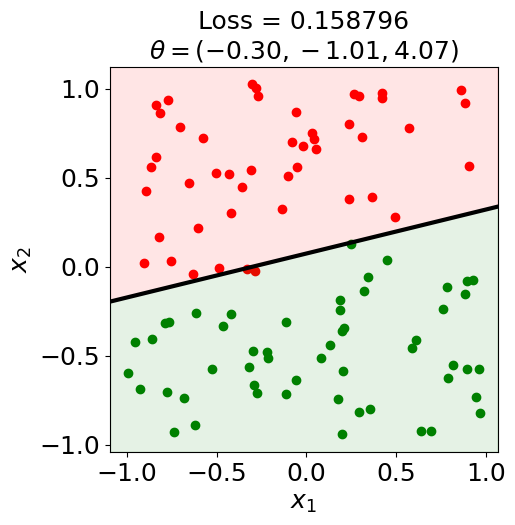

In [16]:
# 模型参数
θ = [model.intercept_[0], model.coef_[0][0], model.coef_[0][1]]

# 创建画布
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# 调用辅助函数
visualize_classification(ax, x_sample, y_sample, θ)

# 添加标题
loss = loss_fn(x_tilde, y_sample, θ)
ax.set_title(f"Loss = {loss:.6f}\n"
             +r"$\theta"+f"=({θ[0]:.2f}, {θ[1]:.2f}, {θ[2]:.2f})$", size=18)

# 显示图像
plt.show()